# Chat ou Chien !! une méthode d'apprentissage automatique.

Dans une entreprise de marketing, on veut faire une étude sur les clients qui fréquentent un grand magasin. L'idée est d'estimer le pourcentage de clients qui ont des chats et ceux qui ont des chiens, afin de prendre des décisions marketing ciblées. Vous proposez d'utiliser une caméra pour détecter et compter les deux animaux dans le magasin. La première étape du projet est de développer un modèle qui peut détecter le chat ou le chien. Ainsi, dans ce brief, en utilisant une base de données, vous allez entrainer un modèle d'apprentissage automatique avec un apprentissage supervisé.

# Veille technologique: Opencv python

- Préparation données imagerie pour méthode classique d'apprentissage automatique
- Entrainement et évaluation (similaire aux briefs précédents)

## Operations Simples

In [2]:
# use opencv to load and display the image
import os
import cv2
import numpy as np

# on fait un test avec une image de chat au hasard (opencv)
chat = cv2.imread("PetImages/Cat/12.jpg")
cv2.imshow("photo_chat", chat)
cv2.waitKey(3000)
cv2.destroyAllWindows()

In [3]:
# Préparer data 
size = 150
# repertoire d'images avec deux sous dossiers "Cat" et "Dog"

images = []  # liste pour images  
label = []  # liste pour Label (0 ou 1) pour deux classes.

# utiliser "os" pour avoir les noms des images dans chaque sous dossier
base_path = "PetImages"
cat_images = os.path.join(base_path, "Cat")
dog_images = os.path.join(base_path, "Dog")

cat_files = [f for f in os.listdir(cat_images) if f.endswith('.jpg')]
dog_files = [f for f in os.listdir(dog_images) if f.endswith('.jpg')]

print(f"Nombre de chats trouvés : {len(cat_files)}")
print(f"Nombre de chiens trouvés : {len(dog_files)}")




Nombre de chats trouvés : 12500
Nombre de chiens trouvés : 12499


In [ ]:
# utiliser une boucle pour lire chaque image, redimensionner en (150,150,3),
# et la mettre dans images, et mettre le label(0 ou 1) selon le type dans "label"

# il y a des images corrumpues, utiliser try ... catch except pour les ignorer


# on crée une fonction pour charger les images d'un dossier
def load_data(directory, files, target_label):
    count = 0
    for f in files: 
        
        path = os.path.join(directory, f)
        try:
            # 1. Lecture de l'image
            img = cv2.imread(path)
            
            # Vérification si l'image est lisible
            if img is not None:
                # 2. Redimensionnement (150, 150)
                img = cv2.resize(img, (size, size))
                
                # 3. Ajout aux listes
                images.append(img)
                label.append(target_label)
                count += 1
        except Exception as e:
            # On ignore les images corrompues
            continue

# Chargement des chats (Label 0)
print("Chargement des chats...")
load_data(cat_images, cat_files, 0)

# Chargement des chiens (Label 1)
print("Chargement des chiens...")
load_data(dog_images, dog_files, 1)

# Conversion en tableaux Numpy (essentiel pour TensorFlow)
X = np.array(images)
y = np.array(label)

# ON RAJOUTE UNE NORMALISATION ICI (pixels des données d'entrainement entre 0 et 1) poru améliorer les perfs de notre modèle

X = X.astype('float32') / 255.0

# show shape
print(f"Forme finale de X : {X.shape}") # Devrait être (Total, 150, 150, 3)
print(f"Forme finale de y : {y.shape}")



Chargement des chats...
Chargement des chiens...
Forme finale de X : (24996, 150, 150, 3)
Forme finale de y : (24996,)


In [ ]:
# prepare data for classical machine learning model

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# utiliser reshape pour redimensionner les données images (exemple: (120,150,150,3) ---> (120,150*150*3)
# n_samples = X.shape[0]


X_flat = X.reshape(n_samples, -1)
y = y.flatten()

print(f"Nouvelle forme de X (flat) : {X.shape}") 







In [7]:
# split les données en train et test avec "stratification"

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.20, 
                                                    stratify=y, 
                                                    random_state=42)

print(f"Entraînement de : {X_train.shape[0]} images")
print(f"Test sur : {X_test.shape[0]} images")

Entraînement de : 19996 images
Test sur : 5000 images


In [37]:
# initialiser le classifier
model_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)


# entrainer le classifier
print("entrainement du modèle Random Forest...")
model_rf.fit(X_train, y_train)


entrainement du modèle Random Forest...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
# evaluate classifier
from sklearn.metrics import classification_report
# predire
y_pred = model_rf.predict(X_test)



In [39]:
# evaluer avec classification_report
print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred, target_names=['Chat', 'Chien']))


--- Rapport de Classification ---
              precision    recall  f1-score   support

        Chat       0.64      0.71      0.67      2500
       Chien       0.67      0.60      0.63      2500

    accuracy                           0.66      5000
   macro avg       0.66      0.66      0.65      5000
weighted avg       0.66      0.66      0.65      5000



Accuracy très mauvaise (66%)...

### Essayer de normaliser chaque image entre 0 et 255 et rentrainer le modèle. Y a-t-il une amélioration ?

In [40]:
# on normalise les données X entre 0 et 1 avec:

# X = X.astype('float32') / 255.0

# et on réentraîne notre modèle




--> Après normalisation, il n'y a aucune amélioration significative. C'est normal car mathématiquement cela ne change rien pour notre algorithme Random Forest. RF est aveugle aux formes d'ou l'intéret d'utiliser un CNN.

# Neural network MLP

Entrainer un modèle MLP pour detecter la class Dog ou Cat.

In [9]:
# use PCA to reduce dimensions
# check this tuto: https://www.askpython.com/python/examples/principal-component-analysis-for-image-data

from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

# creer un reseau de neurone avec une couche d'entrée de taille (150*150*3), deux couches caché de taille 128 et une activation "relu". 
# Dernière couche de taille 1 avec une activation sigmoid. Choisir la bonne "loss function" et "optimizer"

model = Sequential([
    # Couche d'entrée qui aplatit l'image (150, 150, 3) -> (67500,)
    Input(shape=(150, 150, 3)),
    
    Flatten(),
    # Deux couches cachées de 128 neurones
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    
    # Dernière couche pour la classification binaire
    Dense(1, activation='sigmoid')
])

# Choix de la Loss et de l'Optimizer
model.compile(
    optimizer='adam',                # Le standard qui s'adapte tout seul
    loss='binary_crossentropy',      # INDISPENSABLE pour du 0/1 (chien/chat)
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,656,769 (33.02 MB)

 Trainable params: 8,656,769 (33.02 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# split les données en train et test avec "stratification"

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.20, 
                                                    stratify=y, 
                                                    random_state=42, 
                                                    shuffle=True)

print(f"Entraînement de : {X_train.shape[0]} images")
print(f"Test sur : {X_test.shape[0]} images")

Entraînement de : 19996 images
Test sur : 5000 images


In [11]:
# entrainer le modèle avec validation_split = 0.2, epochs = 20, et un batch_size = 128


history = model.fit(
    X_train,             
    y_train,                   
    epochs=20,          
    batch_size=128,      
    validation_split=0.2, 
    verbose=1            
)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.5068 - loss: 554.7228 - val_accuracy: 0.5670 - val_loss: 49.1620
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.5329 - loss: 74.1025 - val_accuracy: 0.4972 - val_loss: 67.7422
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.5294 - loss: 54.8469 - val_accuracy: 0.4945 - val_loss: 115.4956
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.5503 - loss: 26.9650 - val_accuracy: 0.5077 - val_loss: 17.0785
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.5446 - loss: 15.3175 - val_accuracy: 0.4935 - val_loss: 16.1094
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.5646 - loss: 8.2357 - val_accuracy: 0.4938 - val_loss: 21.0498
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.5182 - loss: 34.2321 - val_accuracy: 0.4945 - val_loss: 88.4432
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.5327 - loss

In [12]:
# evaluate MLP
# evaluate classifier
from sklearn.metrics import classification_report
# predire
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)
# evaluer avec classification_report
print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred_classes))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.69      0.17      0.28      2500
           1       0.53      0.92      0.67      2500

    accuracy                           0.55      5000
   macro avg       0.61      0.55      0.47      5000
weighted avg       0.61      0.55      0.47      5000



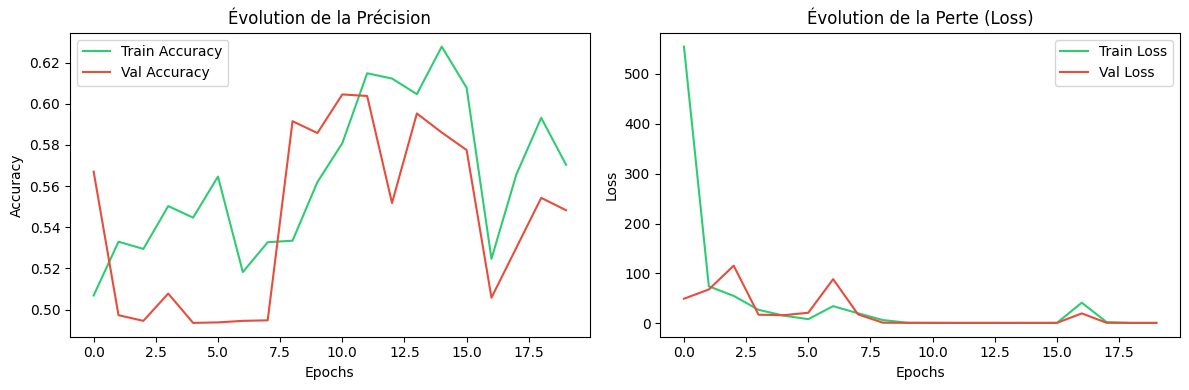

In [15]:
import matplotlib.pyplot as plt


# Courbes d'apprentissage (Loss & Acc)

def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Graphique de l'Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#e74c3c')
    plt.title('Évolution de la Précision')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Graphique de la Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='#2ecc71')
    plt.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
    plt.title('Évolution de la Perte (Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

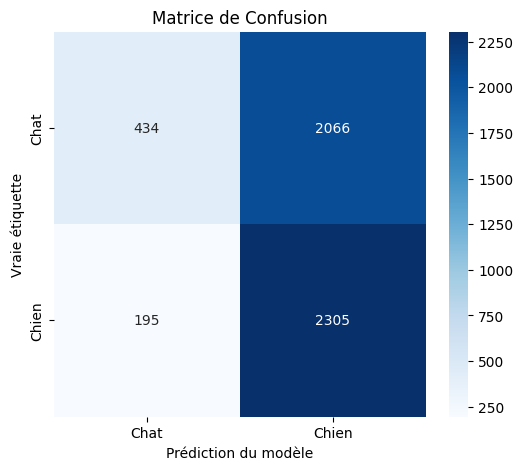

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Calcul de la matrice
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Chat', 'Chien'], 
            yticklabels=['Chat', 'Chien'])
plt.title('Matrice de Confusion')
plt.ylabel('Vraie étiquette')
plt.xlabel('Prédiction du modèle')
plt.show()

BILAN: Le modèle est très instable et n'arrive pas à généraliser, c'est les montagnes russes (cf courbe d'accuracy). De plus, le modèle est devenu "fainéant" et il prédit presque tout le temps la même chose (classe chien) comme on peut le constater sur la matrice de confusion. Le modèle mémorise le bruit ou mise sur la classe majoritaire mais ne parvient pas à véritablement raisonner. 

Solution: CNN

# Normalisation d'image

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
 
img = cv2.imread('PetImages/Cat/100.jpg',0)
cv2.imshow("photo_chat", img)
cv2.waitKey(3000)
cv2.destroyAllWindows()




C:\Users\lucas.fandinoperez\AppData\Local\Temp\ipykernel_14996\2300951737.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


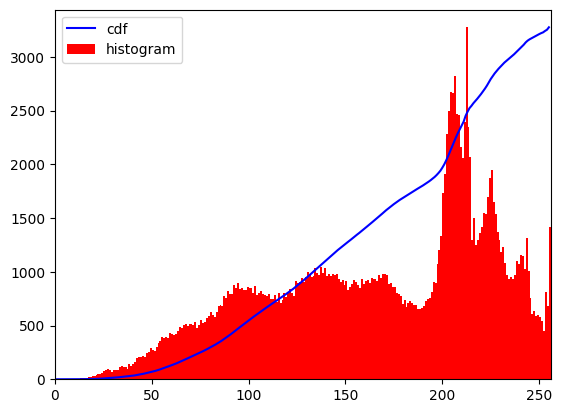

In [3]:
hist,bins = np.histogram(img.flatten(),256,[0,256])
 
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max()/ cdf.max()
 
plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

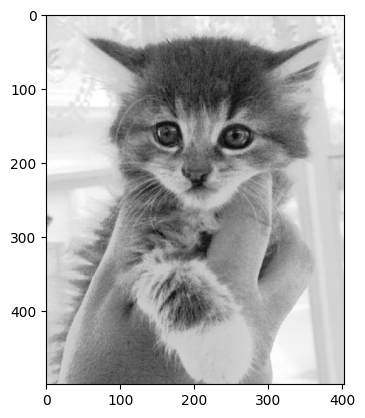

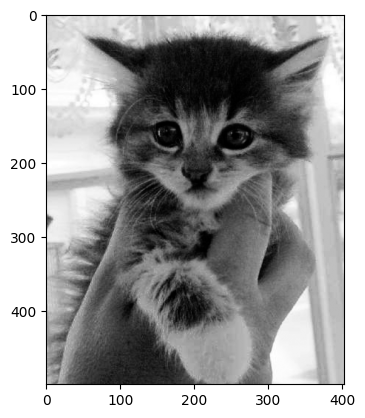

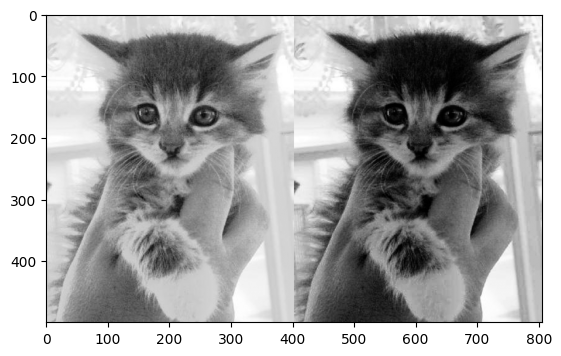

In [4]:
img = cv2.imread('PetImages/Cat/100.jpg',0)

equ = cv2.equalizeHist(img)

res = np.hstack((img,equ)) #stacking images side-by-side

cv2.imwrite('res.png',res)
 
plt.imshow(img,cmap='gray')

plt.show()

plt.imshow(equ,cmap='gray')

plt.show()
 
img2 = cv2.imread('res.png',0)

plt.imshow(img2,cmap='gray')
 